In [1]:
# Cell 1 — Clone dataset
!git clone https://github.com/RABKKK/CableDrivenRobotCableModel.git
import os
files = os.listdir('CableDrivenRobotCableModel')
print(files)

Cloning into 'CableDrivenRobotCableModel'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 81 (delta 0), reused 0 (delta 0), pack-reused 78 (from 1)
Receiving objects: 100% (81/81), 307.47 MiB | 24.97 MiB/s, done.
Resolving deltas: 100% (21/21), done.
Updating files: 100% (42/42), done.
['baumer_video0026p1.avi', 'baumer_video0050.avi', 'baumer_video0043.avi', 'baumer_video0031.avi', '.git', 'baumer_video0032.avi', 'SmallWorskpaceCableDrivenRob.zip', 'baumer_video0049.avi', 'README.md', 'baumer12mm1mfretake.yml', 'baumer_video0033.avi', 'baumer_video0028p2.avi', 'Database', 'baumer_video0045.avi', 'baumer_video0048.avi', 'baumer_video0044.avi', 'baumer_video0027p3.avi']


In [4]:
import cv2
import matplotlib.pyplot as plt
import glob
import os

videos = glob.glob('CableDrivenRobotCableModel/**/*.avi', recursive=True)
print(f"Total videos found: {len(videos)}")
for v in videos:
    print(v)

Total videos found: 26
CableDrivenRobotCableModel/baumer_video0026p1.avi
CableDrivenRobotCableModel/baumer_video0050.avi
CableDrivenRobotCableModel/baumer_video0043.avi
CableDrivenRobotCableModel/baumer_video0031.avi
CableDrivenRobotCableModel/baumer_video0032.avi
CableDrivenRobotCableModel/baumer_video0049.avi
CableDrivenRobotCableModel/baumer_video0033.avi
CableDrivenRobotCableModel/baumer_video0028p2.avi
CableDrivenRobotCableModel/baumer_video0045.avi
CableDrivenRobotCableModel/baumer_video0048.avi
CableDrivenRobotCableModel/baumer_video0044.avi
CableDrivenRobotCableModel/baumer_video0027p3.avi
CableDrivenRobotCableModel/Database/P3/baumer_video0043.avi
CableDrivenRobotCableModel/Database/P3/baumer_video0045.avi
CableDrivenRobotCableModel/Database/P3/baumer_video0044.avi
CableDrivenRobotCableModel/Database/P2/baumer_video0050.avi
CableDrivenRobotCableModel/Database/P2/baumer_video0049.avi
CableDrivenRobotCableModel/Database/P2/baumer_video0048.avi
CableDrivenRobotCableModel/Database

Video: CableDrivenRobotCableModel/baumer_video0026p1.avi
Total frames: 100, FPS: 25.0


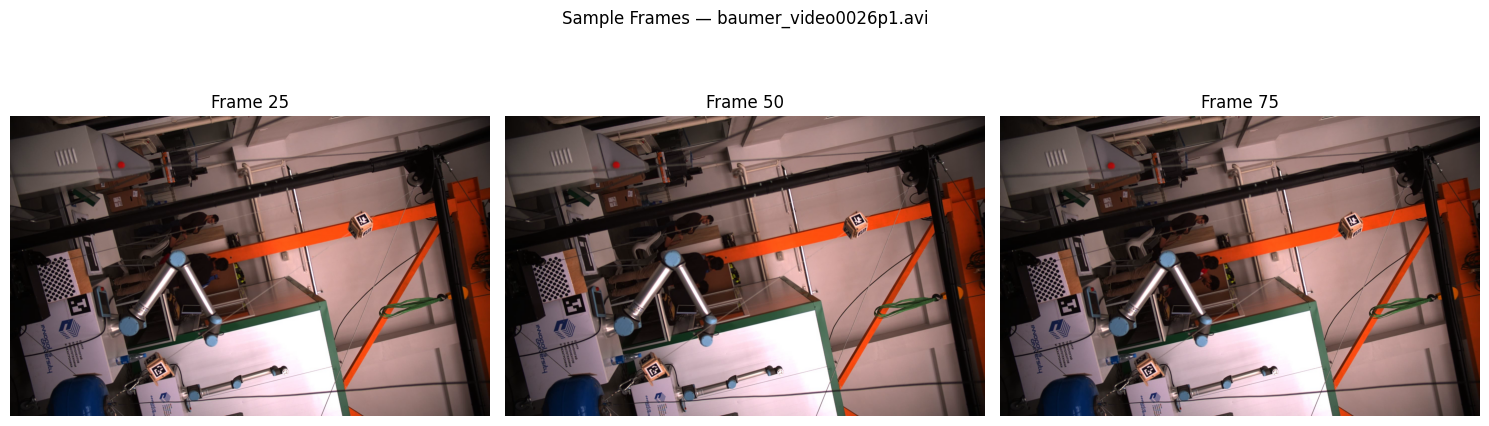

In [5]:
# Cell 2 - Extract frames from first video and display samples
video_path = videos[0]
cap = cv2.VideoCapture(video_path)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
print(f"Video: {video_path}")
print(f"Total frames: {total_frames}, FPS: {fps}")

# Extract 3 evenly spaced frames
frame_indices = [total_frames//4, total_frames//2, 3*total_frames//4]
frames = []
for idx in frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        frames.append(frame)
cap.release()

# Display the 3 frames
fig, axes = plt.subplots(1, len(frames), figsize=(15, 5))
for i, (ax, frame) in enumerate(zip(axes, frames)):
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Frame {frame_indices[i]}')
    ax.axis('off')
plt.suptitle(f'Sample Frames — {os.path.basename(video_path)}')
plt.tight_layout()
plt.savefig('sample_frames.png', dpi=150)
plt.show()

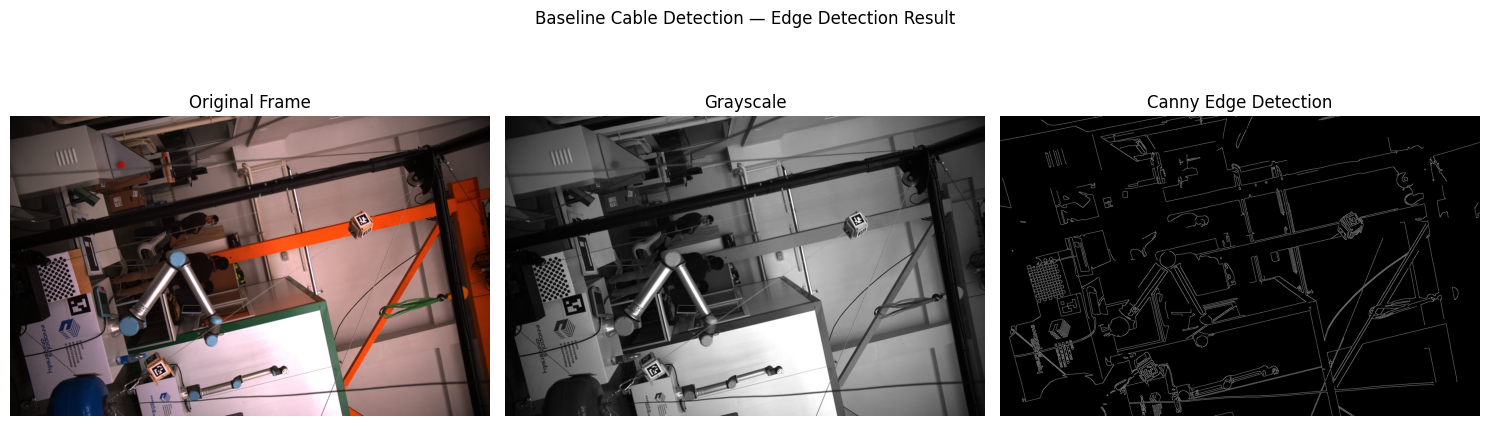

In [6]:
# Cell 3 - Baseline edge detection on one extracted frame
frame = frames[1]  # middle frame
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)); axes[0].set_title('Original Frame'); axes[0].axis('off')
axes[1].imshow(gray, cmap='gray'); axes[1].set_title('Grayscale'); axes[1].axis('off')
axes[2].imshow(edges, cmap='gray'); axes[2].set_title('Canny Edge Detection'); axes[2].axis('off')
plt.suptitle('Baseline Cable Detection — Edge Detection Result')
plt.tight_layout()
plt.savefig('baseline_result.png', dpi=150)
plt.show()

In [7]:
# Cell 4 - Save extracted frames as images to a folder
os.makedirs('extracted_frames', exist_ok=True)
saved = 0
for vid_path in videos[:3]:  # process first 3 videos
    cap = cv2.VideoCapture(vid_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    for idx in [total//4, total//2, 3*total//4]:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            out_path = f"extracted_frames/frame_{os.path.basename(vid_path)}_{idx}.jpg"
            cv2.imwrite(out_path, frame)
            saved += 1
    cap.release()
print(f"Saved {saved} frames to extracted_frames/")

Saved 9 frames to extracted_frames/
